# Uncertainty and Sensor Robustness

Real irrigation monitoring systems do not always provide clean and complete measurements. Sensors can become noisy, measurements can be lost, and communication problems can create gaps in the data.

The previous experiments showed that the physics-guided LSTM can capture part of the soil-moisture dynamics, particularly during drying events, but its predictions are not equally reliable under all conditions.

In this notebook, I will investigate how the forecasting system behaves when the input measurements become uncertain or incomplete.

The experiments will focus on:

- adding controlled noise to soil-moisture measurements
- removing 5%, 10% and 20% of selected sensor observations
- measuring how forecast error changes as data quality decreases
- comparing different types of sensor disturbance
- estimating prediction uncertainty

The aim is not only to obtain a soil-moisture forecast, but also to understand when that forecast becomes less reliable. This information will later be used when developing the irrigation decision model.

In [1]:
# Load the processed field dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "../data/processed/irrigation_model_data.csv"

data = pd.read_csv(
    data_path,
    parse_dates=["Timestamps"]
)

data = data.sort_values(
    "Timestamps"
).reset_index(drop=True)

print("Rows:", len(data))
print("Columns:", len(data.columns))

print("\nStart:", data["Timestamps"].min())
print("End:", data["Timestamps"].max())

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isna().sum())

Rows: 11770
Columns: 10

Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00

Columns:
['Timestamps', 'Port1', 'Port2', 'Port3', 'Port4', 'Port5', 'Port6', 'Rainfall', 'Irrigation', 'Temperature']

Missing values:
Timestamps       0
Port1            0
Port2            0
Port3            0
Port4            0
Port5            0
Port6            0
Rainfall         0
Irrigation     652
Temperature      0
dtype: int64


In [2]:
# Step 181: Establish the clean soil-sensor reference

soil_features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6"
]

soil_summary = data[soil_features].describe().T[
    ["count", "mean", "std", "min", "max"]
]

print("Soil-moisture reference summary:")
print(soil_summary)

print("\nMissing soil-moisture observations:")
print(data[soil_features].isna().sum())

print(
    "\nTotal missing soil observations:",
    data[soil_features].isna().sum().sum()
)

Soil-moisture reference summary:
         count      mean       std    min    max
Port1  11770.0  0.226051  0.037299  0.159  0.339
Port2  11770.0  0.162084  0.041623  0.119  0.286
Port3  11770.0  0.199408  0.039718  0.145  0.320
Port4  11770.0  0.200803  0.026736  0.154  0.321
Port5  11770.0  0.220716  0.041040  0.171  0.366
Port6  11770.0  0.204581  0.046201  0.140  0.350

Missing soil-moisture observations:
Port1    0
Port2    0
Port3    0
Port4    0
Port5    0
Port6    0
dtype: int64

Total missing soil observations: 0


In [3]:
# Create reproducible synthetic sensor dropout

rng = np.random.default_rng(42)

dropout_levels = [0.05, 0.10, 0.20]

port1_dropout = {}

for level in dropout_levels:

    disturbed = data["Port1"].copy()

    n_remove = int(
        len(disturbed) * level
    )

    remove_indices = rng.choice(
        len(disturbed),
        size=n_remove,
        replace=False
    )

    disturbed.iloc[remove_indices] = np.nan

    port1_dropout[level] = disturbed

    print(
        f"{int(level * 100)}% dropout:",
        disturbed.isna().sum(),
        "missing observations"
    )

print(
    "\nOriginal Port1 missing:",
    data["Port1"].isna().sum()
)

5% dropout: 588 missing observations
10% dropout: 1177 missing observations
20% dropout: 2354 missing observations

Original Port1 missing: 0


In [4]:
# Recover synthetic sensor dropout using forward filling

port1_recovered = {}

for level in dropout_levels:

    disturbed = port1_dropout[level].copy()

    recovered = disturbed.ffill()

    # Backfill only if the very first observation happened to be missing
    recovered = recovered.bfill()

    port1_recovered[level] = recovered

    recovery_mae = np.mean(
        np.abs(
            recovered.to_numpy()
            - data["Port1"].to_numpy()
        )
    )

    print(
        f"{int(level * 100)}% dropout"
    )

    print(
        "Missing before recovery:",
        disturbed.isna().sum()
    )

    print(
        "Missing after recovery:",
        recovered.isna().sum()
    )

    print(
        "Recovery MAE:",
        recovery_mae
    )

    print()

5% dropout
Missing before recovery: 588
Missing after recovery: 0
Recovery MAE: 7.561597281223444e-06

10% dropout
Missing before recovery: 1177
Missing after recovery: 0
Recovery MAE: 1.7332200509770618e-05

20% dropout
Missing before recovery: 2354
Missing after recovery: 0
Recovery MAE: 5.6584536958368745e-05



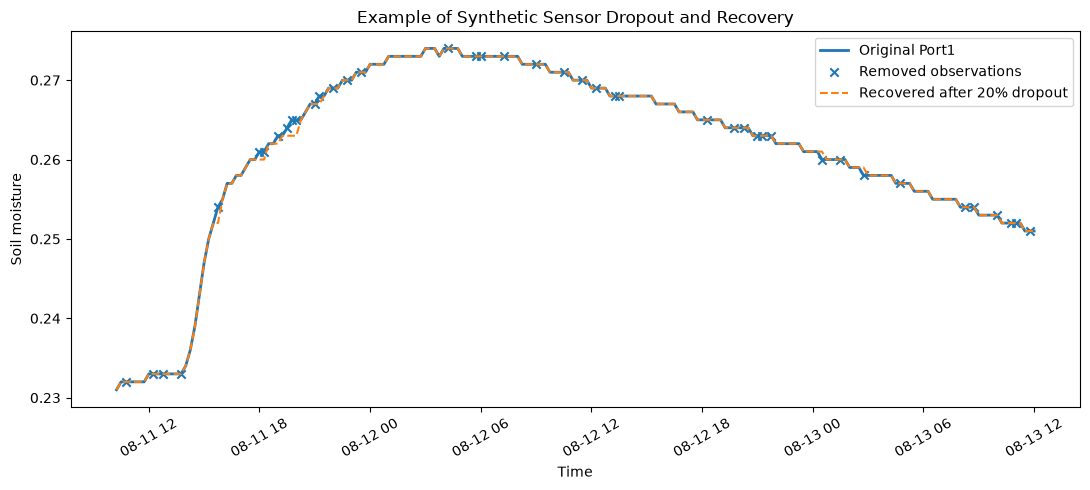

Removed observations in displayed window: 42


In [5]:
# Visualize synthetic sensor dropout and recovery

start_idx = 1000
end_idx = 1200

time_window = data["Timestamps"].iloc[start_idx:end_idx]
original_window = data["Port1"].iloc[start_idx:end_idx]

disturbed_window = (
    port1_dropout[0.20]
    .iloc[start_idx:end_idx]
)

recovered_window = (
    port1_recovered[0.20]
    .iloc[start_idx:end_idx]
)

plt.figure(figsize=(11, 5))

plt.plot(
    time_window,
    original_window,
    label="Original Port1",
    linewidth=2
)

plt.scatter(
    time_window[disturbed_window.isna()],
    original_window[disturbed_window.isna()],
    label="Removed observations",
    marker="x"
)

plt.plot(
    time_window,
    recovered_window,
    label="Recovered after 20% dropout",
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Soil moisture")
plt.title("Example of Synthetic Sensor Dropout and Recovery")

plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(
    "Removed observations in displayed window:",
    disturbed_window.isna().sum()
)

In [6]:
# Check whether Day 4 model objects are available

objects_to_check = [
    "physics_model",
    "physics_feature_scaler",
    "physics_target_scaler",
    "physics_features",
    "device"
]

for name in objects_to_check:
    print(
        name,
        ":",
        "AVAILABLE" if name in globals() else "NOT AVAILABLE"
    )

physics_model : NOT AVAILABLE
physics_feature_scaler : NOT AVAILABLE
physics_target_scaler : NOT AVAILABLE
physics_features : NOT AVAILABLE
device : NOT AVAILABLE


In [7]:
# Set up PyTorch and recreate the model architecture

import torch
import torch.nn as nn

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)


class PhysicsInformedLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        _, (hidden, _) = self.lstm(x)

        last_hidden = hidden[-1]

        prediction = self.fc(
            last_hidden
        )

        return prediction


print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Model class created successfully.")

PyTorch version: 2.14.0
Device: mps
Model class created successfully.


In [8]:
# Recreate the one-hour forecasting target

model_data = data.copy()

# Remove exact duplicate rows
rows_before = len(model_data)

model_data = (
    model_data
    .drop_duplicates()
    .sort_values("Timestamps")
    .reset_index(drop=True)
)

print(
    "Exact duplicate rows removed:",
    rows_before - len(model_data)
)

# Create a unique timestamp lookup
target_lookup = (
    model_data
    .drop_duplicates(
        subset="Timestamps",
        keep="first"
    )
    .set_index("Timestamps")
)

# Exact one-hour-ahead target
model_data["Target_time"] = (
    model_data["Timestamps"]
    + pd.Timedelta(hours=1)
)

model_data["Port1_1h_future"] = (
    target_lookup["Port1"]
    .reindex(model_data["Target_time"])
    .to_numpy()
)

model_data["delta_theta_1h"] = (
    model_data["Port1_1h_future"]
    - model_data["Port1"]
)

print(
    "\nRows after duplicate removal:",
    len(model_data)
)

print(
    "Valid exact 1-hour targets:",
    model_data["Port1_1h_future"]
    .notna()
    .sum()
)

print(
    "Rows without exact target:",
    model_data["Port1_1h_future"]
    .isna()
    .sum()
)

print(
    "\nTarget change range:",
    model_data["delta_theta_1h"].min(),
    "to",
    model_data["delta_theta_1h"].max()
)

Exact duplicate rows removed: 4

Rows after duplicate removal: 11766
Valid exact 1-hour targets: 11449
Rows without exact target: 317

Target change range: -0.01100000000000001 to 0.167


In [9]:
# Recreate physics-guided input features

# Preserve whether irrigation was originally missing
model_data["Irrigation_missing"] = (
    model_data["Irrigation"]
    .isna()
    .astype(int)
)

# Numerical model input
model_data["Irrigation_filled"] = (
    model_data["Irrigation"]
    .fillna(0)
)

# Identify continuous 15-minute sections
time_difference = (
    model_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

new_group = (
    time_difference.ne(15)
)

model_data["continuous_group"] = (
    new_group.cumsum()
)

# Previous-hour rainfall and irrigation
model_data["Rainfall_prev_1h"] = (
    model_data
    .groupby("continuous_group")["Rainfall"]
    .transform(
        lambda x: x.shift(1)
        .rolling(
            window=4,
            min_periods=4
        )
        .sum()
    )
)

model_data["Irrigation_prev_1h"] = (
    model_data
    .groupby("continuous_group")["Irrigation_filled"]
    .transform(
        lambda x: x.shift(1)
        .rolling(
            window=4,
            min_periods=4
        )
        .sum()
    )
)

# Empirical combined water-input indicator
model_data["water_input_prev_1h"] = (
    model_data["Rainfall_prev_1h"]
    + model_data["Irrigation_prev_1h"]
)

physics_features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6",
    "Rainfall",
    "Irrigation_filled",
    "Irrigation_missing",
    "Temperature",
    "Rainfall_prev_1h",
    "Irrigation_prev_1h",
    "water_input_prev_1h"
]

physics_target = "delta_theta_1h"

print("Number of features:", len(physics_features))

print("\nPhysics-guided features:")
for feature in physics_features:
    print(feature)

print(
    "\nMissing irrigation indicators:",
    model_data["Irrigation_missing"].sum()
)

print(
    "Complete previous-hour rainfall:",
    model_data["Rainfall_prev_1h"].notna().sum()
)

print(
    "Complete previous-hour irrigation:",
    model_data["Irrigation_prev_1h"].notna().sum()
)

Number of features: 13

Physics-guided features:
Port1
Port2
Port3
Port4
Port5
Port6
Rainfall
Irrigation_filled
Irrigation_missing
Temperature
Rainfall_prev_1h
Irrigation_prev_1h
water_input_prev_1h

Missing irrigation indicators: 652
Complete previous-hour rainfall: 11434
Complete previous-hour irrigation: 11434


In [10]:
# Build the physics-guided modelling table

required_columns = (
    ["Timestamps"]
    + physics_features
    + [physics_target]
)

physics_data = (
    model_data[required_columns]
    .dropna()
    .sort_values("Timestamps")
    .reset_index(drop=True)
)

print("Rows available for modelling:", len(physics_data))

print(
    "Start:",
    physics_data["Timestamps"].min()
)

print(
    "End:",
    physics_data["Timestamps"].max()
)

print("\nRemaining missing values:")
print(
    physics_data[
        physics_features + [physics_target]
    ].isna().sum()
)

# Chronological 70 / 10 / 20 split
n_total = len(physics_data)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.80)

train_phys = physics_data.iloc[:train_end].copy()
val_phys = physics_data.iloc[train_end:val_end].copy()
test_phys = physics_data.iloc[val_end:].copy()

print("\nTOTAL:", n_total)

print(
    "TRAIN:",
    len(train_phys),
    train_phys["Timestamps"].min(),
    "to",
    train_phys["Timestamps"].max()
)

print(
    "VALIDATION:",
    len(val_phys),
    val_phys["Timestamps"].min(),
    "to",
    val_phys["Timestamps"].max()
)

print(
    "TEST:",
    len(test_phys),
    test_phys["Timestamps"].min(),
    "to",
    test_phys["Timestamps"].max()
)

Rows available for modelling: 11317
Start: 2022-08-01 01:15:00
End: 2023-02-28 22:45:00

Remaining missing values:
Port1                  0
Port2                  0
Port3                  0
Port4                  0
Port5                  0
Port6                  0
Rainfall               0
Irrigation_filled      0
Irrigation_missing     0
Temperature            0
Rainfall_prev_1h       0
Irrigation_prev_1h     0
water_input_prev_1h    0
delta_theta_1h         0
dtype: int64

TOTAL: 11317
TRAIN: 7921 2022-08-01 01:15:00 to 2022-10-22 13:15:00
VALIDATION: 1132 2022-10-22 13:30:00 to 2022-11-03 08:15:00
TEST: 2264 2022-11-03 08:30:00 to 2023-02-28 22:45:00


In [11]:
# Reproduce the original Day 4 chronological split

physics_data = (
    model_data[
        ["Timestamps"]
        + physics_features
        + [physics_target]
    ]
    .loc[
        model_data[physics_target].notna()
    ]
    .sort_values("Timestamps")
    .reset_index(drop=True)
)

n_total = len(physics_data)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.80)

train_phys = physics_data.iloc[
    :train_end
].copy()

val_phys = physics_data.iloc[
    train_end:val_end
].copy()

test_phys = physics_data.iloc[
    val_end:
].copy()

print("TOTAL:", n_total)

print(
    "\nTRAIN:",
    len(train_phys),
    train_phys["Timestamps"].min(),
    "to",
    train_phys["Timestamps"].max()
)

print(
    "\nVALIDATION:",
    len(val_phys),
    val_phys["Timestamps"].min(),
    "to",
    val_phys["Timestamps"].max()
)

print(
    "\nTEST:",
    len(test_phys),
    test_phys["Timestamps"].min(),
    "to",
    test_phys["Timestamps"].max()
)

print("\nMissing previous-hour features:")

print(
    physics_data[
        [
            "Rainfall_prev_1h",
            "Irrigation_prev_1h",
            "water_input_prev_1h"
        ]
    ]
    .isna()
    .sum()
)

TOTAL: 11449

TRAIN: 8014 2022-08-01 00:15:00 to 2022-10-23 11:30:00

VALIDATION: 1145 2022-10-23 11:45:00 to 2022-11-04 09:45:00

TEST: 2290 2022-11-04 10:00:00 to 2023-02-28 22:45:00

Missing previous-hour features:
Rainfall_prev_1h       132
Irrigation_prev_1h     132
water_input_prev_1h    132
dtype: int64


In [12]:
# Create continuous 3-hour sequences

sequence_length = 12


def create_physics_sequences(
    split_data,
    features,
    target,
    sequence_length=12
):

    X = []
    y = []
    timestamps = []

    split_data = (
        split_data
        .sort_values("Timestamps")
        .reset_index(drop=True)
    )

    for end_idx in range(
        sequence_length - 1,
        len(split_data)
    ):

        start_idx = (
            end_idx - sequence_length + 1
        )

        sequence = split_data.iloc[
            start_idx:end_idx + 1
        ]

        # Require exact 15-minute continuity
        time_gaps = (
            sequence["Timestamps"]
            .diff()
            .dropna()
            .dt.total_seconds()
            .div(60)
        )

        if not (time_gaps == 15).all():
            continue

        # Require complete input features
        if sequence[features].isna().any().any():
            continue

        target_value = split_data.loc[
            end_idx,
            target
        ]

        if pd.isna(target_value):
            continue

        X.append(
            sequence[features].to_numpy()
        )

        y.append(
            [target_value]
        )

        timestamps.append(
            split_data.loc[
                end_idx,
                "Timestamps"
            ]
        )

    return (
        np.asarray(X),
        np.asarray(y),
        np.asarray(timestamps)
    )


X_train_phys_raw, y_train_phys_raw, train_phys_times = (
    create_physics_sequences(
        train_phys,
        physics_features,
        physics_target,
        sequence_length
    )
)

X_val_phys_raw, y_val_phys_raw, val_phys_times = (
    create_physics_sequences(
        val_phys,
        physics_features,
        physics_target,
        sequence_length
    )
)

X_test_phys_raw, y_test_phys_raw, test_phys_times = (
    create_physics_sequences(
        test_phys,
        physics_features,
        physics_target,
        sequence_length
    )
)


print(
    "TRAIN:",
    X_train_phys_raw.shape,
    y_train_phys_raw.shape
)

print(
    "VALIDATION:",
    X_val_phys_raw.shape,
    y_val_phys_raw.shape
)

print(
    "TEST:",
    X_test_phys_raw.shape,
    y_test_phys_raw.shape
)

print("\nSequence length:", sequence_length)
print(
    "Number of features:",
    X_train_phys_raw.shape[2]
)

TRAIN: (7999, 12, 13) (7999, 1)
VALIDATION: (1134, 12, 13) (1134, 1)
TEST: (1948, 12, 13) (1948, 1)

Sequence length: 12
Number of features: 13


In [13]:
# Scale features and target using training data only

from sklearn.preprocessing import StandardScaler

physics_feature_scaler = StandardScaler()
physics_target_scaler = StandardScaler()

n_features = X_train_phys_raw.shape[2]


# Fit feature scaler using training observations only
physics_feature_scaler.fit(
    X_train_phys_raw.reshape(-1, n_features)
)


def scale_sequences(X, scaler):

    original_shape = X.shape

    X_scaled = scaler.transform(
        X.reshape(-1, original_shape[2])
    )

    return X_scaled.reshape(original_shape)


X_train_phys = scale_sequences(
    X_train_phys_raw,
    physics_feature_scaler
)

X_val_phys = scale_sequences(
    X_val_phys_raw,
    physics_feature_scaler
)

X_test_phys = scale_sequences(
    X_test_phys_raw,
    physics_feature_scaler
)


# Fit target scaler using training targets only
physics_target_scaler.fit(
    y_train_phys_raw
)

y_train_phys = physics_target_scaler.transform(
    y_train_phys_raw
)

y_val_phys = physics_target_scaler.transform(
    y_val_phys_raw
)

y_test_phys = physics_target_scaler.transform(
    y_test_phys_raw
)


print("TRAIN X:", X_train_phys.shape)
print("TRAIN y:", y_train_phys.shape)

print("\nVALIDATION X:", X_val_phys.shape)
print("VALIDATION y:", y_val_phys.shape)

print("\nTEST X:", X_test_phys.shape)
print("TEST y:", y_test_phys.shape)

print(
    "\nTraining feature mean:",
    np.round(
        X_train_phys.mean(axis=(0, 1)),
        4
    )
)

print(
    "\nTraining target mean:",
    y_train_phys.mean()
)

print(
    "Training target std:",
    y_train_phys.std()
)

TRAIN X: (7999, 12, 13)
TRAIN y: (7999, 1)

VALIDATION X: (1134, 12, 13)
VALIDATION y: (1134, 1)

TEST X: (1948, 12, 13)
TEST y: (1948, 1)

Training feature mean: [-0.  0.  0. -0. -0. -0. -0. -0.  0.  0.  0.  0. -0.]

Training target mean: -1.2436052382349547e-17
Training target std: 1.0


In [14]:
# Convert scaled arrays to PyTorch tensors

from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_train_phys,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_phys,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_phys,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_phys,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_phys,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_phys,
    dtype=torch.float32
)


# Create datasets
train_phys_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_phys_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_phys_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# Same batch size used in Day 4
batch_size = 64

train_phys_loader = DataLoader(
    train_phys_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_phys_loader = DataLoader(
    val_phys_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_phys_loader = DataLoader(
    test_phys_dataset,
    batch_size=batch_size,
    shuffle=False
)


print(
    "Train tensor:",
    X_train_tensor.shape,
    y_train_tensor.shape
)

print(
    "Validation tensor:",
    X_val_tensor.shape,
    y_val_tensor.shape
)

print(
    "Test tensor:",
    X_test_tensor.shape,
    y_test_tensor.shape
)

print("\nTraining batches:", len(train_phys_loader))
print("Validation batches:", len(val_phys_loader))
print("Test batches:", len(test_phys_loader))

Train tensor: torch.Size([7999, 12, 13]) torch.Size([7999, 1])
Validation tensor: torch.Size([1134, 12, 13]) torch.Size([1134, 1])
Test tensor: torch.Size([1948, 12, 13]) torch.Size([1948, 1])

Training batches: 125
Validation batches: 18
Test batches: 31


In [15]:
# Initialize the fixed physics-guided LSTM

import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(seed)


physics_model = PhysicsInformedLSTM(
    input_size=len(physics_features),
    hidden_size=32
).to(device)


# Count trainable parameters
trainable_parameters = sum(
    p.numel()
    for p in physics_model.parameters()
    if p.requires_grad
)


print(physics_model)

print(
    "\nInput features:",
    len(physics_features)
)

print(
    "Hidden units:",
    32
)

print(
    "Trainable parameters:",
    trainable_parameters
)

print(
    "Device:",
    device
)

print(
    "Random seed:",
    seed
)

PhysicsInformedLSTM(
  (lstm): LSTM(13, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Input features: 13
Hidden units: 32
Trainable parameters: 6049
Device: mps
Random seed: 42


In [16]:
# Train the fixed physics-guided LSTM

import copy

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    physics_model.parameters(),
    lr=0.001
)

max_epochs = 40
patience = 6

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0
epochs_without_improvement = 0

train_loss_history = []
val_loss_history = []


for epoch in range(1, max_epochs + 1):


    # Training
    physics_model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_phys_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = physics_model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()
        optimizer.step()

        train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss /= len(train_phys_loader.dataset)


    # Validation

    physics_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_phys_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = physics_model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            val_loss += (
                loss.item() * X_batch.size(0)
            )

    val_loss /= len(val_phys_loader.dataset)


    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.6f} | "
        f"Validation: {val_loss:.6f}"
    )


    # -------------------------
    # Early stopping
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            physics_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


# Restore best validation model
physics_model.load_state_dict(
    best_model_state
)


print(
    "\nBest epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Best validation model restored."
)

Epoch 01 | Train: 0.943060 | Validation: 0.011266
Epoch 02 | Train: 0.880262 | Validation: 0.010636
Epoch 03 | Train: 0.807492 | Validation: 0.009726
Epoch 04 | Train: 0.762727 | Validation: 0.009736
Epoch 05 | Train: 0.719270 | Validation: 0.009985
Epoch 06 | Train: 0.694252 | Validation: 0.009759
Epoch 07 | Train: 0.654264 | Validation: 0.009933
Epoch 08 | Train: 0.621004 | Validation: 0.010173
Epoch 09 | Train: 0.606891 | Validation: 0.010408

Early stopping at epoch 9.

Best epoch: 3
Best validation loss: 0.009725501346919272
Best validation model restored.


In [17]:
# Save the trained model and preprocessing objects

from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)


# Save model checkpoint
checkpoint = {
    "model_state_dict": physics_model.state_dict(),
    "input_size": len(physics_features),
    "hidden_size": 32,
    "sequence_length": sequence_length,
    "physics_features": physics_features,
    "target": physics_target,
    "forecast_horizon_minutes": 60,
    "random_seed": seed,
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss
}

torch.save(
    checkpoint,
    models_dir / "physics_guided_lstm.pth"
)


# Save feature scaler
joblib.dump(
    physics_feature_scaler,
    models_dir / "physics_feature_scaler.pkl"
)


# Save target scaler
joblib.dump(
    physics_target_scaler,
    models_dir / "physics_target_scaler.pkl"
)


print("Saved files:")

for file in sorted(models_dir.iterdir()):

    print(
        file.name,
        "-",
        file.stat().st_size,
        "bytes"
    )

Saved files:
physics_feature_scaler.pkl - 879 bytes
physics_guided_lstm.pth - 27813 bytes
physics_target_scaler.pkl - 591 bytes


In [18]:
# Reload the saved model from disk

# Load checkpoint
loaded_checkpoint = torch.load(
    models_dir / "physics_guided_lstm.pth",
    map_location=device,
    weights_only=False
)

# Recreate a fresh model
loaded_physics_model = PhysicsInformedLSTM(
    input_size=loaded_checkpoint["input_size"],
    hidden_size=loaded_checkpoint["hidden_size"]
).to(device)

# Load learned weights
loaded_physics_model.load_state_dict(
    loaded_checkpoint["model_state_dict"]
)

loaded_physics_model.eval()


# Reload preprocessing objects
loaded_feature_scaler = joblib.load(
    models_dir / "physics_feature_scaler.pkl"
)

loaded_target_scaler = joblib.load(
    models_dir / "physics_target_scaler.pkl"
)


print("Model loaded successfully.")

print(
    "Input size:",
    loaded_checkpoint["input_size"]
)

print(
    "Hidden size:",
    loaded_checkpoint["hidden_size"]
)

print(
    "Sequence length:",
    loaded_checkpoint["sequence_length"]
)

print(
    "Forecast horizon:",
    loaded_checkpoint["forecast_horizon_minutes"],
    "minutes"
)

print(
    "Best epoch:",
    loaded_checkpoint["best_epoch"]
)

print(
    "Best validation loss:",
    loaded_checkpoint["best_validation_loss"]
)

print(
    "Number of saved features:",
    len(loaded_checkpoint["physics_features"])
)

print(
    "Model device:",
    next(loaded_physics_model.parameters()).device
)

Model loaded successfully.
Input size: 13
Hidden size: 32
Sequence length: 12
Forecast horizon: 60 minutes
Best epoch: 3
Best validation loss: 0.009725501346919272
Number of saved features: 13
Model device: mps:0


In [19]:
# Establish the clean test baseline from the reloaded model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

loaded_physics_model.eval()

with torch.no_grad():

    clean_test_tensor = torch.tensor(
        X_test_phys,
        dtype=torch.float32
    ).to(device)

    clean_predictions_scaled = (
        loaded_physics_model(clean_test_tensor)
        .cpu()
        .numpy()
    )


# Convert predictions back to original target scale
clean_predictions = (
    loaded_target_scaler.inverse_transform(
        clean_predictions_scaled
    )
    .ravel()
)

clean_targets = (
    y_test_phys_raw
    .ravel()
)


# Calculate clean test performance
clean_mae = mean_absolute_error(
    clean_targets,
    clean_predictions
)

clean_rmse = np.sqrt(
    mean_squared_error(
        clean_targets,
        clean_predictions
    )
)

clean_r2 = r2_score(
    clean_targets,
    clean_predictions
)


print("Clean test sequences:", len(clean_targets))

print(
    "Prediction range:",
    clean_predictions.min(),
    "to",
    clean_predictions.max()
)

print(
    "Observed range:",
    clean_targets.min(),
    "to",
    clean_targets.max()
)

print("\nClean test performance")

print("MAE :", clean_mae)
print("RMSE:", clean_rmse)
print("R²  :", clean_r2)

Clean test sequences: 1948
Prediction range: -0.0009153531 to 0.0005793865
Observed range: -0.0020000000000000018 to 0.010999999999999982

Clean test performance
MAE : 0.0003999094900460232
RMSE: 0.0008168561883423058
R²  : -0.14397895768645008


In [20]:
# Test model sensitivity to missing Port1 measurements

dropout_levels = [0.05, 0.10, 0.20]
dropout_results = []

port1_index = physics_features.index("Port1")

rng = np.random.default_rng(42)

for dropout in dropout_levels:

    X_disturbed = X_test_phys_raw.copy()

    total_values = (
        X_disturbed.shape[0]
        * X_disturbed.shape[1]
    )

    n_remove = int(
        total_values * dropout
    )

    flat_indices = rng.choice(
        total_values,
        size=n_remove,
        replace=False
    )

    row_indices = (
        flat_indices // X_disturbed.shape[1]
    )

    time_indices = (
        flat_indices % X_disturbed.shape[1]
    )

    # Remove selected Port1 observations
    X_disturbed[
        row_indices,
        time_indices,
        port1_index
    ] = np.nan

    # Recover missing values using past observations only
    for i in range(X_disturbed.shape[0]):

        port1_values = X_disturbed[
            i, :, port1_index
        ]

        for t in range(1, len(port1_values)):

            if np.isnan(port1_values[t]):
                port1_values[t] = port1_values[t - 1]

        X_disturbed[
            i, :, port1_index
        ] = port1_values

    remaining_missing = np.isnan(
        X_disturbed[:, :, port1_index]
    ).sum()

    print(
        f"{int(dropout * 100)}% missing:",
        n_remove,
        "values removed |",
        remaining_missing,
        "still missing"
    )

    dropout_results.append(
        {
            "dropout": dropout,
            "data": X_disturbed
        }
    )

5% missing: 1168 values removed | 97 still missing
10% missing: 2337 values removed | 193 still missing
20% missing: 4675 values removed | 484 still missing


In [21]:
# Recover first-position sensor gaps using the last available past reading

for result in dropout_results:

    X_disturbed = result["data"]

    for i in range(X_disturbed.shape[0]):

        port1_values = X_disturbed[
            i, :, port1_index
        ]

        # If the first reading is missing, use the last known
        # Port1 value before this sequence began
        if np.isnan(port1_values[0]):

            sequence_start = pd.Timestamp(
                test_phys_times[i]
            ) - pd.Timedelta(
                minutes=15 * (sequence_length - 1)
            )

            previous_time = (
                sequence_start
                - pd.Timedelta(minutes=15)
            )

            previous_values = model_data.loc[
                model_data["Timestamps"] == previous_time,
                "Port1"
            ]

            if len(previous_values) > 0:
                port1_values[0] = previous_values.iloc[-1]

        # Continue forward through the sequence
        for t in range(1, len(port1_values)):

            if np.isnan(port1_values[t]):
                port1_values[t] = port1_values[t - 1]

        X_disturbed[
            i, :, port1_index
        ] = port1_values

    result["data"] = X_disturbed

    remaining_missing = np.isnan(
        X_disturbed[:, :, port1_index]
    ).sum()

    print(
        f"{int(result['dropout'] * 100)}% missing:",
        remaining_missing,
        "values still missing"
    )

5% missing: 0 values still missing
10% missing: 0 values still missing
20% missing: 0 values still missing


In [22]:
# Evaluate forecasting performance as Port1 measurements are lost

robustness_metrics = [
    {
        "Missing data": "0%",
        "MAE": clean_mae,
        "RMSE": clean_rmse,
        "R2": clean_r2
    }
]

for result in dropout_results:

    X_disturbed = result["data"].copy()

    # Scale using the original training-fitted scaler
    X_disturbed_scaled = scale_sequences(
        X_disturbed,
        loaded_feature_scaler
    )

    X_disturbed_tensor = torch.tensor(
        X_disturbed_scaled,
        dtype=torch.float32
    ).to(device)

    loaded_physics_model.eval()

    with torch.no_grad():

        predictions_scaled = (
            loaded_physics_model(
                X_disturbed_tensor
            )
            .cpu()
            .numpy()
        )

    predictions = (
        loaded_target_scaler
        .inverse_transform(
            predictions_scaled
        )
        .ravel()
    )

    mae = mean_absolute_error(
        clean_targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            clean_targets,
            predictions
        )
    )

    r2 = r2_score(
        clean_targets,
        predictions
    )

    mae_change = (
        (mae - clean_mae)
        / clean_mae
        * 100
    )

    rmse_change = (
        (rmse - clean_rmse)
        / clean_rmse
        * 100
    )

    robustness_metrics.append(
        {
            "Missing data":
                f"{int(result['dropout'] * 100)}%",
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

    print(
        f"{int(result['dropout'] * 100)}% missing"
    )
    print(f"MAE:  {mae:.8f}")
    print(f"RMSE: {rmse:.8f}")
    print(f"R²:   {r2:.6f}")
    print(
        f"MAE change from clean: "
        f"{mae_change:+.2f}%"
    )
    print(
        f"RMSE change from clean: "
        f"{rmse_change:+.2f}%"
    )
    print()

5% missing
MAE:  0.00039990
RMSE: 0.00081682
R²:   -0.143873
MAE change from clean: -0.00%
RMSE change from clean: -0.00%

10% missing
MAE:  0.00039991
RMSE: 0.00081681
R²:   -0.143853
MAE change from clean: -0.00%
RMSE change from clean: -0.01%

20% missing
MAE:  0.00039987
RMSE: 0.00081641
R²:   -0.142728
MAE change from clean: -0.01%
RMSE change from clean: -0.05%



In [23]:
# Repeat the dropout experiment across several random sensor-failure patterns

dropout_levels = [0.05, 0.10, 0.20]
seeds = range(10)

repeated_results = []

port1_index = physics_features.index("Port1")

for dropout in dropout_levels:

    for random_seed in seeds:

        rng = np.random.default_rng(random_seed)

        X_disturbed = X_test_phys_raw.copy()

        total_values = (
            X_disturbed.shape[0]
            * X_disturbed.shape[1]
        )

        n_remove = int(
            total_values * dropout
        )

        flat_indices = rng.choice(
            total_values,
            size=n_remove,
            replace=False
        )

        row_indices = (
            flat_indices // X_disturbed.shape[1]
        )

        time_indices = (
            flat_indices % X_disturbed.shape[1]
        )

        X_disturbed[
            row_indices,
            time_indices,
            port1_index
        ] = np.nan

        # Recover each sequence using past information only
        for i in range(X_disturbed.shape[0]):

            port1_values = X_disturbed[
                i, :, port1_index
            ]

            if np.isnan(port1_values[0]):

                sequence_start = (
                    pd.Timestamp(test_phys_times[i])
                    - pd.Timedelta(
                        minutes=15 * (sequence_length - 1)
                    )
                )

                previous_time = (
                    sequence_start
                    - pd.Timedelta(minutes=15)
                )

                previous_values = model_data.loc[
                    model_data["Timestamps"] == previous_time,
                    "Port1"
                ]

                if len(previous_values) > 0:
                    port1_values[0] = previous_values.iloc[-1]

            for t in range(1, len(port1_values)):

                if np.isnan(port1_values[t]):
                    port1_values[t] = port1_values[t - 1]

            X_disturbed[
                i, :, port1_index
            ] = port1_values

        # Make sure recovery succeeded
        if np.isnan(
            X_disturbed[:, :, port1_index]
        ).any():
            continue

        X_scaled = scale_sequences(
            X_disturbed,
            loaded_feature_scaler
        )

        X_tensor = torch.tensor(
            X_scaled,
            dtype=torch.float32
        ).to(device)

        loaded_physics_model.eval()

        with torch.no_grad():

            pred_scaled = (
                loaded_physics_model(X_tensor)
                .cpu()
                .numpy()
            )

        predictions = (
            loaded_target_scaler
            .inverse_transform(pred_scaled)
            .ravel()
        )

        mae = mean_absolute_error(
            clean_targets,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                clean_targets,
                predictions
            )
        )

        repeated_results.append(
            {
                "Missing data (%)": int(dropout * 100),
                "Seed": random_seed,
                "MAE": mae,
                "RMSE": rmse
            }
        )


repeated_results_df = pd.DataFrame(
    repeated_results
)

summary = (
    repeated_results_df
    .groupby("Missing data (%)")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std")
    )
)


print(summary)




                  MAE_mean       MAE_std  RMSE_mean      RMSE_std
Missing data (%)                                                 
5                   0.0004  6.556349e-09   0.000817  3.783345e-08
10                  0.0004  8.389739e-09   0.000817  5.059649e-08
20                  0.0004  1.404487e-08   0.000817  8.158122e-08


In [24]:
# Test continuous Port1 sensor outages

outage_hours = [1, 3, 6]
outage_results = []

port1_index = physics_features.index("Port1")

for hours in outage_hours:

    missing_steps = int(hours * 4)

    X_disturbed = X_test_phys_raw.copy()

    # Simulate the sensor becoming unavailable at the end
    # of each forecasting window
    X_disturbed[
        :,
        -missing_steps:,
        port1_index
    ] = np.nan

    # Carry forward the most recent reading that was
    # available before the outage
    for i in range(X_disturbed.shape[0]):

        port1_values = X_disturbed[
            i, :, port1_index
        ]

        for t in range(1, len(port1_values)):

            if np.isnan(port1_values[t]):
                port1_values[t] = port1_values[t - 1]

        X_disturbed[
            i, :, port1_index
        ] = port1_values

    remaining_missing = np.isnan(
        X_disturbed[:, :, port1_index]
    ).sum()

    if remaining_missing > 0:
        print(
            f"{hours} hour outage could not be fully recovered."
        )
        continue

    X_scaled = scale_sequences(
        X_disturbed,
        loaded_feature_scaler
    )

    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    loaded_physics_model.eval()

    with torch.no_grad():

        pred_scaled = (
            loaded_physics_model(X_tensor)
            .cpu()
            .numpy()
        )

    predictions = (
        loaded_target_scaler
        .inverse_transform(pred_scaled)
        .ravel()
    )

    mae = mean_absolute_error(
        clean_targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            clean_targets,
            predictions
        )
    )

    r2 = r2_score(
        clean_targets,
        predictions
    )

    outage_results.append(
        {
            "Outage (hours)": hours,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

    print(f"{hours} hour outage")
    print(f"MAE:  {mae:.8f}")
    print(f"RMSE: {rmse:.8f}")
    print(f"R²:   {r2:.6f}")
    print(
        "MAE change from clean:",
        f"{((mae / clean_mae) - 1) * 100:+.2f}%"
    )
    print(
        "RMSE change from clean:",
        f"{((rmse / clean_rmse) - 1) * 100:+.2f}%"
    )
    print()

1 hour outage
MAE:  0.00039973
RMSE: 0.00081470
R²:   -0.137953
MAE change from clean: -0.04%
RMSE change from clean: -0.26%

3 hour outage could not be fully recovered.
6 hour outage could not be fully recovered.


In [25]:
# Continuous Port1 outage

outage_hours = [1, 3]
outage_results = []

for hours in outage_hours:

    missing_steps = hours * 4
    X_disturbed = X_test_phys_raw.copy()

    X_disturbed[
        :, -missing_steps:, port1_index
    ] = np.nan

    for i in range(len(X_disturbed)):

        values = X_disturbed[i, :, port1_index]

        if np.isnan(values[0]):

            sequence_start = (
                pd.Timestamp(test_phys_times[i])
                - pd.Timedelta(
                    minutes=15 * (sequence_length - 1)
                )
            )

            previous_time = (
                sequence_start
                - pd.Timedelta(minutes=15)
            )

            previous_value = model_data.loc[
                model_data["Timestamps"] == previous_time,
                "Port1"
            ]

            if len(previous_value):
                values[0] = previous_value.iloc[-1]

        for t in range(1, len(values)):
            if np.isnan(values[t]):
                values[t] = values[t - 1]

        X_disturbed[i, :, port1_index] = values

    remaining = np.isnan(
        X_disturbed[:, :, port1_index]
    ).sum()

    if remaining:
        print(
            f"{hours} hour outage: "
            f"{remaining} unresolved values"
        )
        continue

    X_scaled = scale_sequences(
        X_disturbed,
        loaded_feature_scaler
    )

    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        pred_scaled = (
            loaded_physics_model(X_tensor)
            .cpu()
            .numpy()
        )

    predictions = (
        loaded_target_scaler
        .inverse_transform(pred_scaled)
        .ravel()
    )

    mae = mean_absolute_error(
        clean_targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            clean_targets,
            predictions
        )
    )

    r2 = r2_score(
        clean_targets,
        predictions
    )

    outage_results.append({
        "Outage (hours)": hours,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{hours} hour outage")
    print(f"MAE:  {mae:.8f}")
    print(f"RMSE: {rmse:.8f}")
    print(f"R²:   {r2:.6f}")
    print(
        "MAE change:",
        f"{((mae / clean_mae) - 1) * 100:+.2f}%"
    )
    print(
        "RMSE change:",
        f"{((rmse / clean_rmse) - 1) * 100:+.2f}%"
    )
    print()

1 hour outage
MAE:  0.00039973
RMSE: 0.00081470
R²:   -0.137953
MAE change: -0.04%
RMSE change: -0.26%

3 hour outage
MAE:  0.00039793
RMSE: 0.00080914
R²:   -0.122467
MAE change: -0.50%
RMSE change: -0.94%



In [26]:
# Soil-moisture sensor noise experiment

soil_features = [
    "Port1", "Port2", "Port3",
    "Port4", "Port5", "Port6"
]

soil_indices = [
    physics_features.index(name)
    for name in soil_features
]

training_sensor_std = (
    X_train_phys_raw[:, :, soil_indices]
    .reshape(-1, len(soil_indices))
    .std(axis=0)
)

noise_levels = [0.01, 0.05, 0.10]
noise_results = []

for noise_level in noise_levels:

    trial_metrics = []

    for seed_value in range(10):

        rng = np.random.default_rng(seed_value)

        X_noisy = X_test_phys_raw.copy()

        for j, feature_index in enumerate(soil_indices):

            noise = rng.normal(
                loc=0.0,
                scale=(
                    noise_level
                    * training_sensor_std[j]
                ),
                size=X_noisy[:, :, feature_index].shape
            )

            X_noisy[:, :, feature_index] += noise

        X_scaled = scale_sequences(
            X_noisy,
            loaded_feature_scaler
        )

        X_tensor = torch.tensor(
            X_scaled,
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():

            pred_scaled = (
                loaded_physics_model(X_tensor)
                .cpu()
                .numpy()
            )

        predictions = (
            loaded_target_scaler
            .inverse_transform(pred_scaled)
            .ravel()
        )

        mae = mean_absolute_error(
            clean_targets,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                clean_targets,
                predictions
            )
        )

        trial_metrics.append(
            [mae, rmse]
        )

    trial_metrics = np.array(
        trial_metrics
    )

    noise_results.append({
        "Noise (%)": int(noise_level * 100),
        "MAE mean": trial_metrics[:, 0].mean(),
        "MAE std": trial_metrics[:, 0].std(),
        "RMSE mean": trial_metrics[:, 1].mean(),
        "RMSE std": trial_metrics[:, 1].std()
    })

noise_results_df = pd.DataFrame(
    noise_results
)

print(noise_results_df.to_string(index=False))

 Noise (%)  MAE mean      MAE std  RMSE mean     RMSE std
         1    0.0004 3.811087e-08   0.000817 3.436332e-08
         5    0.0004 1.916723e-07   0.000817 1.703069e-07
        10    0.0004 3.874009e-07   0.000817 3.369260e-07


In [27]:
# Compare sensor-noise results with the clean forecast

noise_comparison = noise_results_df.copy()

noise_comparison["MAE change (%)"] = (
    (noise_comparison["MAE mean"] - clean_mae)
    / clean_mae
    * 100
)

noise_comparison["RMSE change (%)"] = (
    (noise_comparison["RMSE mean"] - clean_rmse)
    / clean_rmse
    * 100
)

print(
    noise_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.10f}"
    )
)

 Noise (%)     MAE mean      MAE std    RMSE mean     RMSE std  MAE change (%)  RMSE change (%)
         1 0.0003999299 0.0000000381 0.0008168765 0.0000000344    0.0051007476     0.0024858264
         5 0.0004000498 0.0000001917 0.0008170188 0.0000001703    0.0350759872     0.0199072488
        10 0.0004002877 0.0000003874 0.0008173337 0.0000003369    0.0945793532     0.0584563869


Random measurement noise had little effect on the forecast, so I next considered a different type of sensor uncertainty. Instead of disturbing individual measurements, I removed complete soil-sensor inputs to examine how much the forecast depends on having measurements from all six sensing ports.

In [28]:
# Loss of multiple soil sensors

sensor_loss_results = []

sensor_groups = {
    "Port1": ["Port1"],
    "Port1-Port2": ["Port1", "Port2"],
    "Port1-Port3": ["Port1", "Port2", "Port3"],
    "Port1-Port4": ["Port1", "Port2", "Port3", "Port4"],
    "All soil sensors": [
        "Port1", "Port2", "Port3",
        "Port4", "Port5", "Port6"
    ]
}

for label, missing_sensors in sensor_groups.items():

    X_disturbed = X_test_phys_raw.copy()

    for sensor in missing_sensors:

        feature_index = physics_features.index(sensor)

        training_mean = X_train_phys_raw[
            :, :, feature_index
        ].mean()

        X_disturbed[
            :, :, feature_index
        ] = training_mean

    X_scaled = scale_sequences(
        X_disturbed,
        loaded_feature_scaler
    )

    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        pred_scaled = (
            loaded_physics_model(X_tensor)
            .cpu()
            .numpy()
        )

    predictions = (
        loaded_target_scaler
        .inverse_transform(pred_scaled)
        .ravel()
    )

    mae = mean_absolute_error(
        clean_targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            clean_targets,
            predictions
        )
    )

    sensor_loss_results.append({
        "Unavailable sensors": label,
        "MAE": mae,
        "RMSE": rmse,
        "MAE change (%)":
            ((mae / clean_mae) - 1) * 100,
        "RMSE change (%)":
            ((rmse / clean_rmse) - 1) * 100
    })

sensor_loss_df = pd.DataFrame(
    sensor_loss_results
)

print(
    sensor_loss_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

Unavailable sensors        MAE       RMSE  MAE change (%)  RMSE change (%)
              Port1 0.00025200 0.00077405    -36.98611029      -5.24081433
        Port1-Port2 0.00052984 0.00086801     32.48879018       6.26179327
        Port1-Port3 0.00052612 0.00086920     31.56052456       6.40806155
        Port1-Port4 0.00055213 0.00088390     38.06429239       8.20787614
   All soil sensors 0.00038575 0.00080908     -3.53983485      -0.95147607


Removing complete soil-sensor inputs produced a different response from adding random measurement noise. Forecast error did not increase uniformly as more sensors were removed. Removing Port1 alone reduced the aggregate MAE, while removing Port1 together with additional sensors increased the error by approximately 32% to 38%. Removing all six soil sensors again produced a small reduction in the aggregate error. These results should not be interpreted as evidence that sensor loss improves forecasting. The target distribution contains many small soil-moisture changes, and replacing sensor measurements with their training means can move the model toward more conservative predictions. The experiment instead shows that the model's sensitivity depends on which soil-state measurements remain available.

In [29]:
# Sensor loss during meaningful soil-moisture changes

event_mask = np.abs(clean_targets) >= 0.001

print(
    "Meaningful events:",
    event_mask.sum(),
    "of",
    len(clean_targets)
)

event_results = []

for label, missing_sensors in sensor_groups.items():

    X_disturbed = X_test_phys_raw.copy()

    for sensor in missing_sensors:

        feature_index = physics_features.index(sensor)

        training_mean = X_train_phys_raw[
            :, :, feature_index
        ].mean()

        X_disturbed[
            :, :, feature_index
        ] = training_mean

    X_scaled = scale_sequences(
        X_disturbed,
        loaded_feature_scaler
    )

    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        pred_scaled = (
            loaded_physics_model(X_tensor)
            .cpu()
            .numpy()
        )

    predictions = (
        loaded_target_scaler
        .inverse_transform(pred_scaled)
        .ravel()
    )

    event_mae = mean_absolute_error(
        clean_targets[event_mask],
        predictions[event_mask]
    )

    event_rmse = np.sqrt(
        mean_squared_error(
            clean_targets[event_mask],
            predictions[event_mask]
        )
    )

    event_results.append({
        "Unavailable sensors": label,
        "Event MAE": event_mae,
        "Event RMSE": event_rmse
    })

event_sensor_loss_df = pd.DataFrame(
    event_results
)

print(
    event_sensor_loss_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)

Meaningful events: 270 of 1948
Unavailable sensors  Event MAE  Event RMSE
              Port1 0.00135379  0.00206618
        Port1-Port2 0.00124540  0.00208264
        Port1-Port3 0.00125519  0.00209568
        Port1-Port4 0.00124481  0.00209732
   All soil sensors 0.00129752  0.00208242


The test set contained 270 meaningful soil-moisture changes out of 1,948 forecasts. When the analysis was restricted to these events, the differences between sensor-loss scenarios became much smaller than those observed with the overall MAE. This indicates that the large changes in aggregate error were strongly influenced by the many periods in which soil moisture changed very little. The results also show that aggregate forecasting metrics alone can give a misleading picture of model behaviour when the target distribution is concentrated near zero. I therefore considered both overall performance and event-specific performance when assessing sensor robustness.

In [30]:
# Validation residuals for uncertainty calibration

X_val_tensor = torch.tensor(
    X_val_phys,
    dtype=torch.float32
).to(device)

loaded_physics_model.eval()

with torch.no_grad():

    val_pred_scaled = (
        loaded_physics_model(X_val_tensor)
        .cpu()
        .numpy()
    )

val_predictions = (
    loaded_target_scaler
    .inverse_transform(val_pred_scaled)
    .ravel()
)

val_targets = (
    loaded_target_scaler
    .inverse_transform(
        y_val_phys.reshape(-1, 1)
    )
    .ravel()
)

val_residuals = np.abs(
    val_targets - val_predictions
)

print("Validation forecasts:", len(val_residuals))
print(
    "Mean absolute residual:",
    f"{val_residuals.mean():.8f}"
)
print(
    "Median absolute residual:",
    f"{np.median(val_residuals):.8f}"
)
print(
    "Largest absolute residual:",
    f"{val_residuals.max():.8f}"
)

Validation forecasts: 1134
Mean absolute residual: 0.00025216
Median absolute residual: 0.00013226
Largest absolute residual: 0.00114600


The validation errors were concentrated near zero, although a smaller number of forecasts had larger residuals. I used these residuals to construct a 90% prediction interval. The interval width was determined from the validation set and then applied unchanged to the test predictions.

In [31]:
# Calibrate a 90% prediction interval

alpha = 0.10
n_cal = len(val_residuals)

conformal_level = (
    np.ceil((n_cal + 1) * (1 - alpha))
    / n_cal
)

conformal_level = min(
    conformal_level,
    1.0
)

q_hat = np.quantile(
    val_residuals,
    conformal_level,
    method="higher"
)

print(
    "Calibration observations:",
    n_cal
)

print(
    "Quantile level:",
    f"{conformal_level:.6f}"
)

print(
    "Uncertainty margin:",
    f"{q_hat:.8f}"
)

Calibration observations: 1134
Quantile level: 0.901235
Uncertainty margin: 0.00088183


In [32]:
# Evaluate the calibrated interval on the test set

lower_bound = clean_predictions - q_hat
upper_bound = clean_predictions + q_hat

covered = (
    (clean_targets >= lower_bound)
    & (clean_targets <= upper_bound)
)

test_coverage = covered.mean() * 100
mean_interval_width = np.mean(
    upper_bound - lower_bound
)

print(
    "Test forecasts:",
    len(clean_targets)
)

print(
    "Target coverage:",
    "90.00%"
)

print(
    "Observed coverage:",
    f"{test_coverage:.2f}%"
)

print(
    "Mean interval width:",
    f"{mean_interval_width:.8f}"
)

print(
    "Forecasts outside interval:",
    (~covered).sum()
)

Test forecasts: 1948
Target coverage: 90.00%
Observed coverage: 93.84%
Mean interval width: 0.00176366
Forecasts outside interval: 120


The 90% interval calibrated on the validation set achieved 93.84% coverage on the unseen test set. Of the 1,948 test forecasts, 120 observations fell outside the interval. The mean interval width was 0.00176366. The observed coverage was higher than the nominal 90% level, indicating that the interval was somewhat conservative on the test period. Importantly, the uncertainty margin was determined before evaluating the test observations and was not adjusted to improve test coverage.

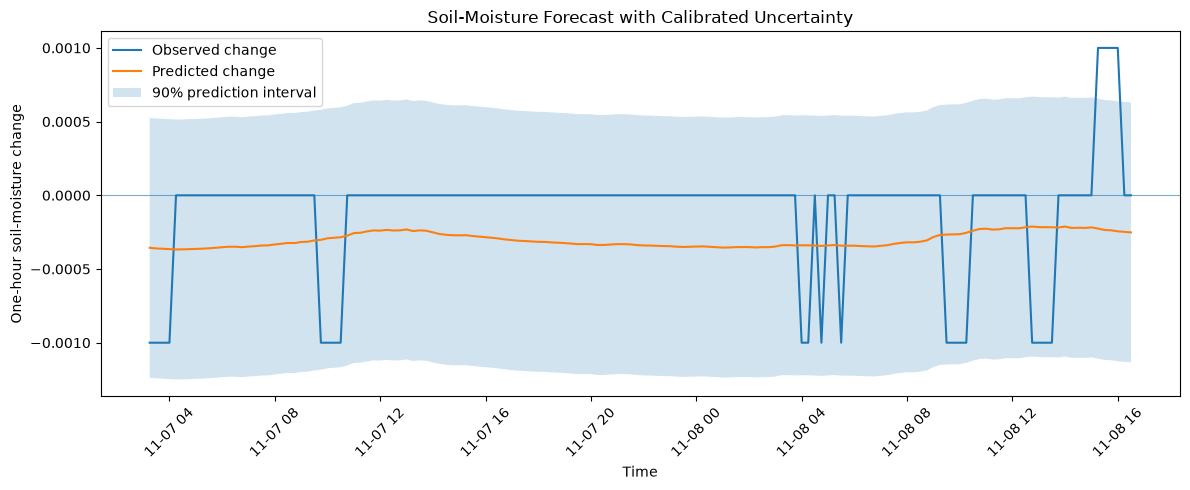

In [33]:
# Forecasts with calibrated uncertainty intervals

plot_start = 250
plot_length = 150

plot_end = plot_start + plot_length

plot_times = test_phys_times[
    plot_start:plot_end
]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_times,
    clean_targets[plot_start:plot_end],
    label="Observed change",
    linewidth=1.5
)

plt.plot(
    plot_times,
    clean_predictions[plot_start:plot_end],
    label="Predicted change",
    linewidth=1.5
)

plt.fill_between(
    plot_times,
    lower_bound[plot_start:plot_end],
    upper_bound[plot_start:plot_end],
    alpha=0.2,
    label="90% prediction interval"
)

plt.axhline(
    0,
    linewidth=0.8,
    alpha=0.6
)

plt.xlabel("Time")
plt.ylabel("One-hour soil-moisture change")
plt.title(
    "Soil-Moisture Forecast with Calibrated Uncertainty"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## What I learned from the robustness tests

The forecasting model was relatively insensitive to small random disturbances in the soil-moisture measurements. Randomly missing Port1 observations and moderate noise across all six soil sensors produced only small changes in the overall forecasting error.

The response was different when complete sensor inputs were removed. The effect depended on which sensors were unavailable, and the overall error was strongly influenced by the large number of periods with very small soil-moisture changes. Looking separately at meaningful moisture changes gave a more useful picture of model behaviour.

The uncertainty analysis also showed that a point forecast alone does not tell the whole story. Using validation residuals, I calibrated a 90% prediction interval with a margin of 0.00088183. On the unseen test period, the interval covered 93.84% of the observations, with 120 of 1,948 forecasts falling outside the interval.

The forecast remains smoother than the observed soil-moisture changes and does not reproduce every sudden wetting or drying event. This is an important limitation of the current model and will be considered when the forecasts are used for irrigation decisions.